In [10]:
import sys
import os

# Настраиваем путь к модулям
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

# Импортируем свои модели
from src.regression import LinearRegressionAnalytics, LinearRegressionGD
from src.scalers import StandardScaler


plt.style.use('ggplot')

## Класс модели для аналитического решения

## Класс модели для градиентного спуска

## Функция для визуализации

In [11]:
def visualize_model(X, y, model, normalize_features=False, normalize_target=False):
    """Делит данные на обучающие и тестовые,
    обучает и тестирует модель, визуализирует предсказания и веса.
    Генерация признаков происходит при создании X_clean и X_red.
    X_clean - признаки без линейных зависимостей,
    например: X, X^2, X^3
    X_red - признаки с линейными зависимостями,
    например: X, X^2, X^3, 6*X
    Меняя признаки, можно регулировать степень полинома или
    нелинейность данных.
    Args:
        X: Исходные входные данные, например числа от 0 до 10 с шагом 0.1
        y: Выходные данные, полученные некой функцией f(X)
        model: Модель, которая будет обучена и протестирована
    """
    X_clean = np.array([[x, x**2, x**3] for x in X])
    X_red = np.array([[x, x**2, x**3, 6*x] for x in X])

    datasets = [X_clean, X_red]
    
    y_train = y[::2]
    y_test = y[1::2]

    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(14, 9))
    for i, dataset in enumerate(datasets):
            
        X_train = dataset[::2]
        X_test = dataset[1::2]
        if normalize_features:
            f_scaler = StandardScaler()
            X_train = f_scaler.fit_transform(X_train)
            X_test = f_scaler.transform(X_test)

        t_scaler = StandardScaler()
        if normalize_target:
            y_train = t_scaler.fit_transform(y_train)
            y_test = t_scaler.transform(y_test)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        if normalize_target:
            y_pred = t_scaler.inverse_transform(y_pred)
            y_test = t_scaler.inverse_transform(y_test)
            y_train = t_scaler.inverse_transform(y_train)
        
        ax[i][0].scatter(X_test[:, 0], y_test, label='Тестовые данные')
        ax[i][0].scatter(X_train[:, 0], y_train, label='Обучающие данные')
        ax[i][0].plot(X_test[:, 0], y_pred, label='Прогноз', c='g', lw=3)

        mse = np.mean((y_test - y_pred) ** 2)
        ax[i][0].set_title(f'MSE: {mse:.2f}')
        ax[i][0].legend()
        weights = [f'w{j+1}' for j in range(model.w_.shape[0])]
        ax[i][1].bar(x=weights, height=model.w_)
        ax[i][1].set_title('Значения весов (без b)')
    ax[0][0].set_ylabel('Линейно независимые данные')
    ax[1][0].set_ylabel('Линейно зависимые данные')
    plt.tight_layout()
    plt.show()


## Генерация данных

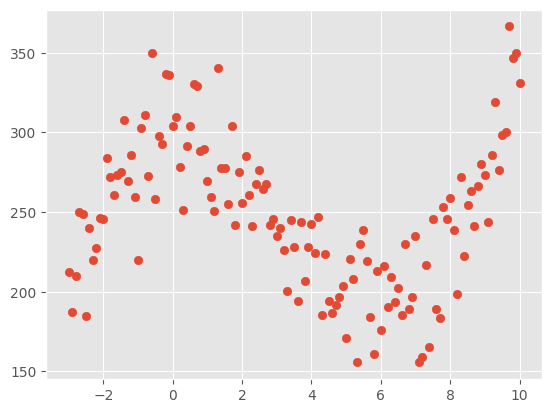

In [12]:
np.random.seed(0)

X = np.arange(-3, 10.1, 0.1)
y = X**3 - 10 * X**2 + 5*X  + 300 + np.random.normal(0.0, 25, size=X.shape)

plt.scatter(X, y)
plt.show()

# Полиномиальная регрессия аналитически, без регуляризации

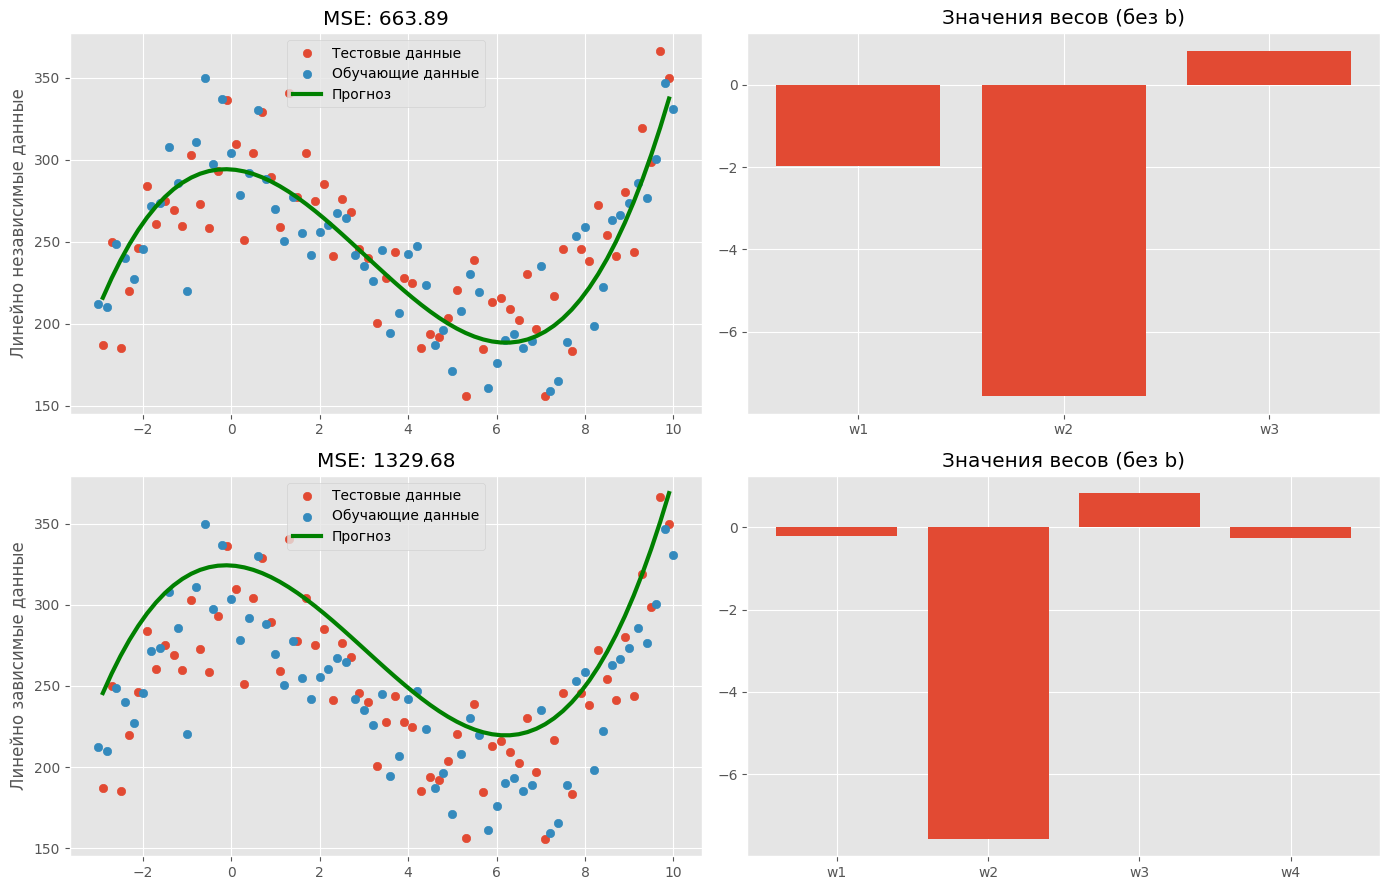

In [13]:
lr_a = LinearRegressionAnalytics(l2_coef=0.0)
visualize_model(X, y, lr_a)

# Полиномиальная регрессия аналитически, L2-регуляризация

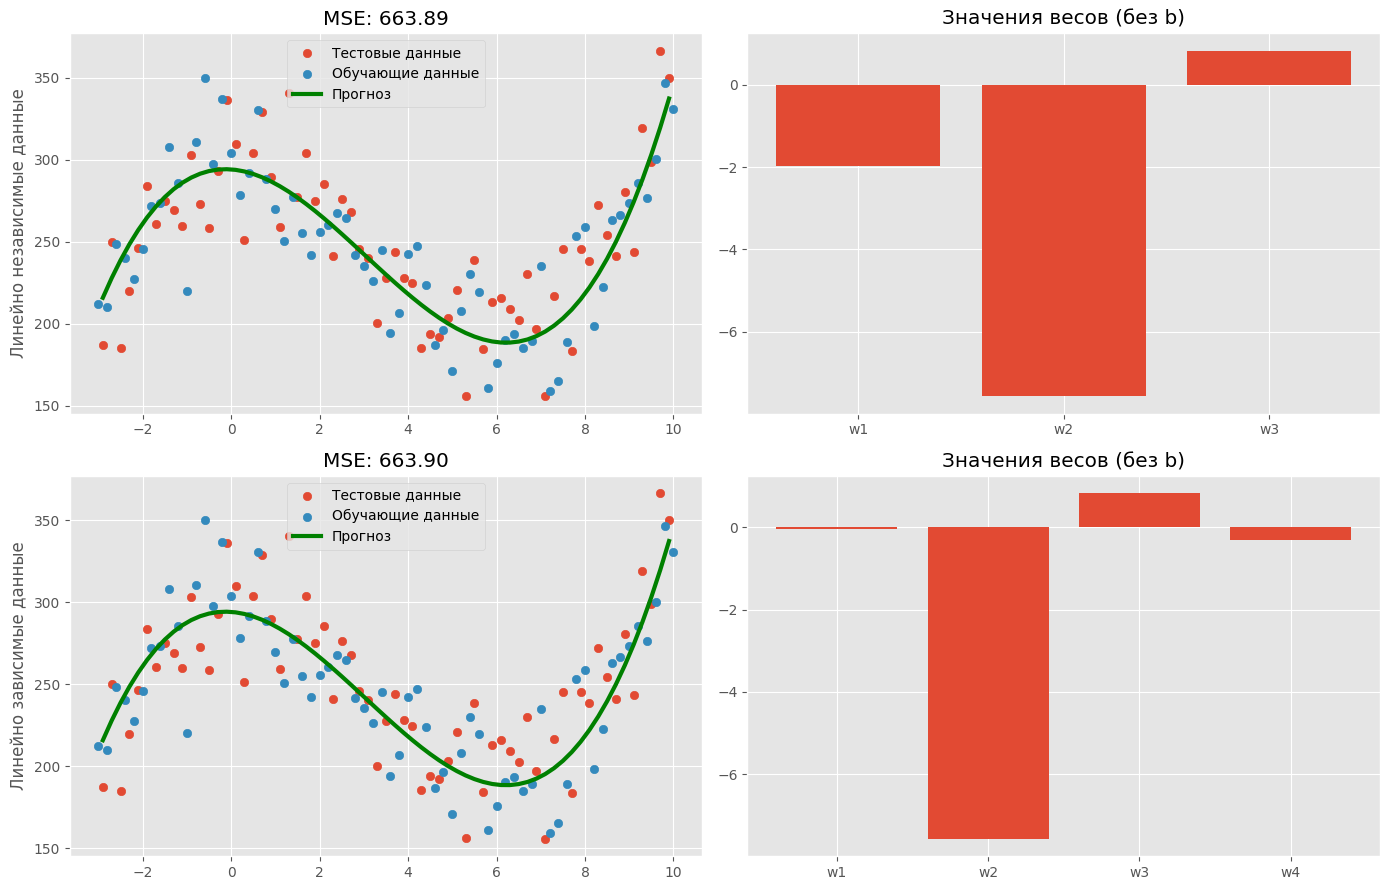

In [14]:
lr_a_l2 = LinearRegressionAnalytics(l2_coef=0.05)
visualize_model(X, y, lr_a_l2)

# Полиномиальная регрессия полным градиентным спуском, без регуляризации

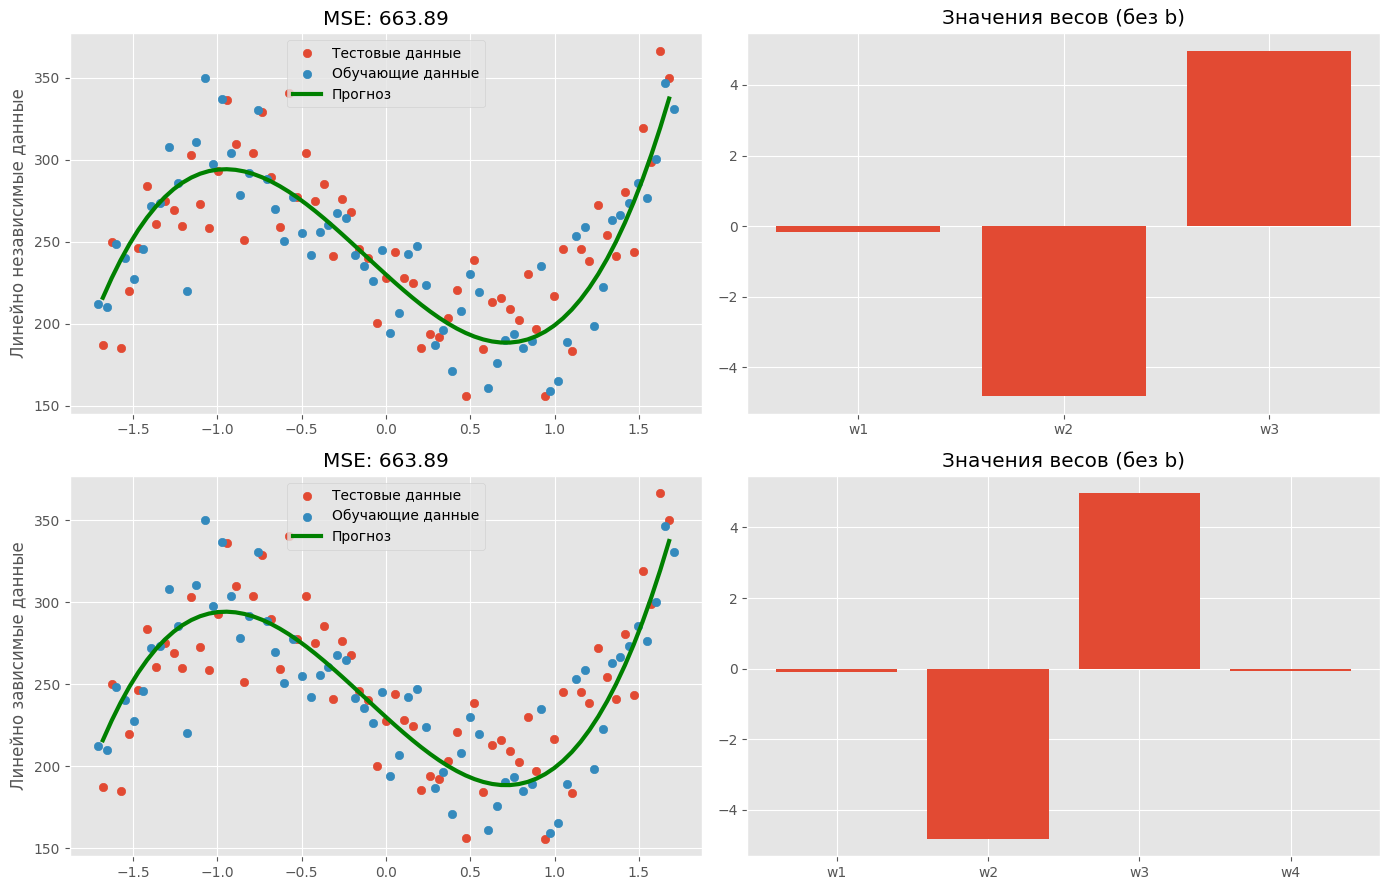

In [15]:
lr_GD = LinearRegressionGD(eta=0.25, n_iter=5000, l2_coef=0.0)

visualize_model(X, y, lr_GD, normalize_features=True, normalize_target=True)

# Полиномиальная регрессия полным градиентным спуском, L2-регуляризация

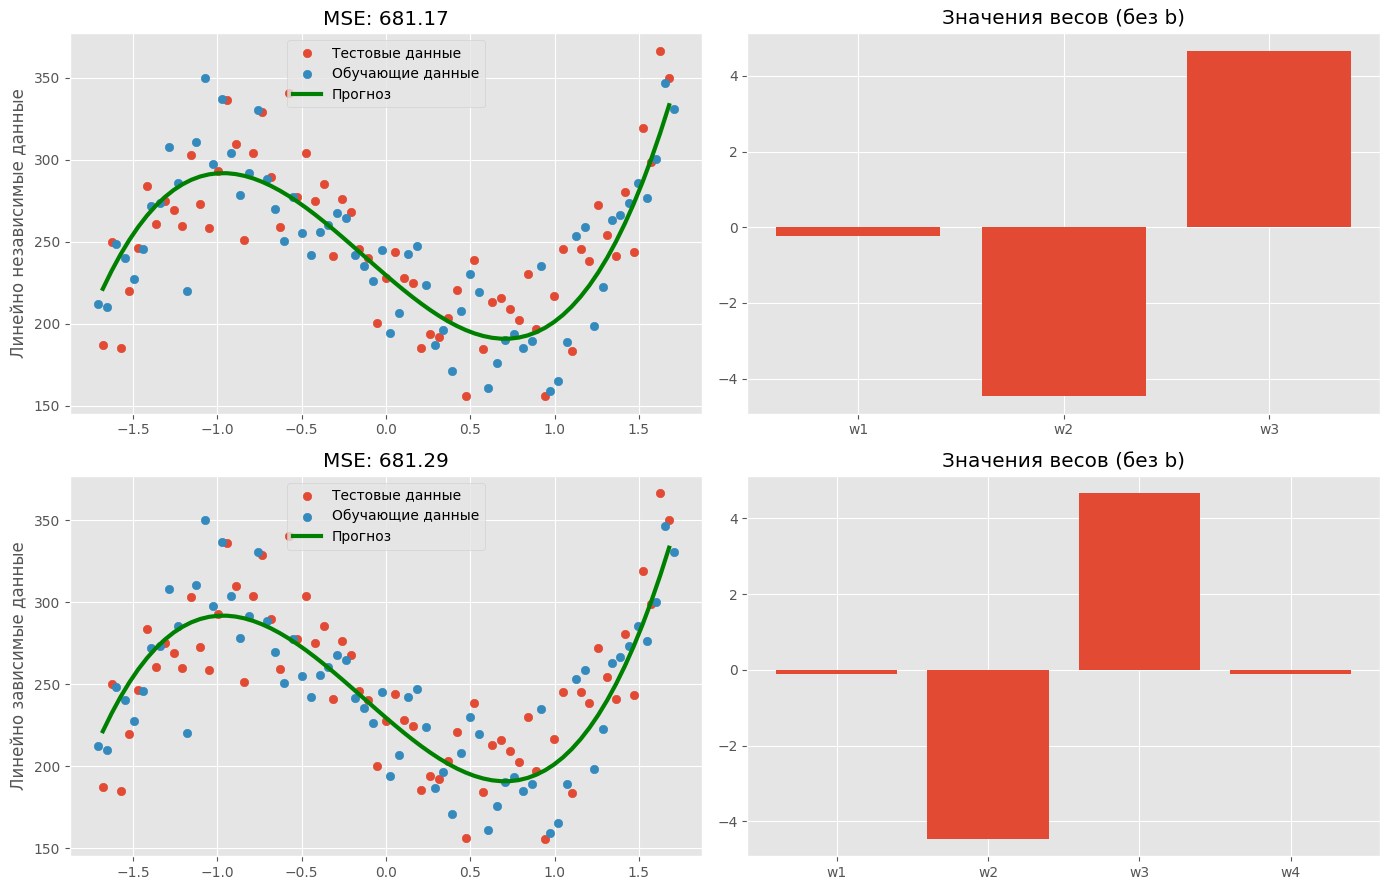

In [16]:
lr_GD_l2 = LinearRegressionGD(eta=0.25, n_iter=5000, l2_coef=0.05)

visualize_model(X, y, lr_GD_l2, normalize_features=True, normalize_target=True)

In [17]:
np.mean(y, axis=0)

248.4018714962677

In [18]:
np.std(y, axis=0)

46.638506893681374